# Demonstrasi Eigenfaces & Analisis Aljabar Linear (SVD)

Demonstrasikan tugas tambahan pada analisis Eigenfaces berbasis **Singular Value Decomposition (SVD)**. 

### **Instruksi Tugas Tambahan:**
1. Menampilkan satu gambar wajah tunggal.
2. Menampilkan matriks piksel dari gambar tersebut.
3. Memecah matriks gambar (proses *Flattening* dari 2D menjadi vektor 1D, serta rekonstruksi kembali/*Reshaping*).
4. Mengetahui ukuran-ukuran matriks (dimensi sebelum dan sesudah dipecah).
5. Mengetahui matriks hasil dekomposisi SVD ($U$, $S$, dan $V^T$ Transpose) serta ukurannya.

## 1 & 2. Menampilkan Gambar Tunggal & Matriks Piksel Gambar

Setiap gambar dibaca oleh pustaka OpenCV (`cv2`) sebagai matriks 2D angka piksel (bernilai `0` untuk hitam sempurna hingga `255` untuk putih sempurna). 
Di bawah ini, kita akan membaca salah satu file dari dataset wajah asli Olivetti (`face_000.png`) menggunakan skala abu-abu (*grayscale*), lalu menampilkan nilai matriks serta visualisasi gambarnya.

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Definisikan path relatif gambar (satu tingkat di bawah folder demo-eigenfaces.ipynb)
path_gambar = "5-vektor/eigenfaces/face_000.png"
gambar = cv2.imread(path_gambar, cv2.IMREAD_GRAYSCALE)

if gambar is None:
    print("[-] ERROR: Gambar tidak ditemukan! Cek apakah folder '5-vektor/eigenfaces' sudah terisi dataset.")
else:
    print("[+] Gambar berhasil dibaca!")
    print("\n=== MATRIKS GAMBAR (ANGKA PIKSEL 2D) ===")
    print(gambar)
    print(f"\nTipe Data Matriks: {gambar.dtype}")

[+] Gambar berhasil dibaca!

=== MATRIKS GAMBAR (ANGKA PIKSEL 2D) ===
[[ 50  60  89 ... 128 134 134]
 [ 49  62  92 ... 128 131 134]
 [ 50  64  91 ... 130 130 133]
 ...
 [ 91 145 142 ...  29  20  25]
 [142 154 147 ...  18  18  32]
 [159 150 160 ...  15  32  23]]

Tipe Data Matriks: uint8


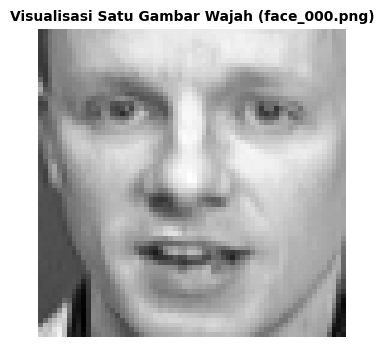

In [2]:
# Visualisasikan gambar menggunakan matplotlib
if gambar is not None:
    plt.figure(figsize=(4, 4))
    plt.imshow(gambar, cmap='gray')
    plt.title("Visualisasi Satu Gambar Wajah (face_000.png)", fontsize=10, fontweight='bold')
    plt.axis('off')
    plt.show()

## 3. Memecah Matriks (Flattening & Reshaping)

* **Flattening (Memecah):** Mengubah matriks 2D (piksel tinggi x lebar) menjadi vektor baris/kolom 1D linear berukuran panjang (tinggi * lebar). Hal ini mempermudah operasi matriks aljabar linear.
* **Reshaping (Menyusun Kembali):** Mengembalikan vektor 1D berukuran panjang tersebut kembali menjadi bentuk matriks 2D semula untuk keperluan rendering/visualisasi grafis.

In [3]:
if gambar is not None:
    # A. Proses memecah matriks 2D (64x64) menjadi vektor 1D (4096)
    vektor_pecah = gambar.flatten()
    print("=== PROSES MEMECAH MATRIKS (FLATTENING) ===")
    print(f"Vektor 1D (10 elemen pertama) : {vektor_pecah[:10]}")
    
    # B. Proses menyusun kembali vektor 1D (4096) menjadi matriks 2D (64x64)
    matriks_kembali = vektor_pecah.reshape(64, 64)
    print("\n=== PROSES MENYUSUN KEMBALI (RESHAPING) ===")
    print(f"Matriks 2D disusun kembali.")
    print(f"Apakah matriks hasil rekonsiliasi sama persis dengan aslinya? {np.array_equal(gambar, matriks_kembali)}")

=== PROSES MEMECAH MATRIKS (FLATTENING) ===
Vektor 1D (10 elemen pertama) : [ 50  60  89 104 107 109 127 134 133 141]

=== PROSES MENYUSUN KEMBALI (RESHAPING) ===
Matriks 2D disusun kembali.
Apakah matriks hasil rekonsiliasi sama persis dengan aslinya? True


## 4. Mengetahui Ukuran-Ukuran Matriks

Gunakan atribut `.shape` dari Numpy untuk mengetahui secara pasti dimensi dimensi dari matriks sebelum dan sesudah dipecah.

In [4]:
if gambar is not None:
    print("=== INFORMASI UKURAN MATRIKS ===")
    print(f"1. Dimensi Matriks Gambar Asli (2D)     : {gambar.shape} (Artinya: 64 baris x 64 kolom piksel)")
    print(f"2. Dimensi Vektor Setelah Dipecah (1D)  : {vektor_pecah.shape} (Artinya: 4096 elemen baris linear)")

=== INFORMASI UKURAN MATRIKS ===
1. Dimensi Matriks Gambar Asli (2D)     : (64, 64) (Artinya: 64 baris x 64 kolom piksel)
2. Dimensi Vektor Setelah Dipecah (1D)  : (4096,) (Artinya: 4096 elemen baris linear)


## 5. Mengetahui Matriks Dekomposisi SVD ($U$, $S$, $V^T$)

Dekomposisi SVD memecah matriks data gabungan wajah terpusat $A$ ($4096 \times N$) menjadi perkalian tiga buah matriks:

$$A = U \cdot \Sigma \cdot V^T$$

Di mana:
* **Matriks $U$ (Left Singular Vectors / Eigenfaces):** Menyimpan arah variasi bentuk wajah terbesar.
* **Matriks $S$ (Singular Values / $\Sigma$):** Menyimpan tingkat bobot energi informasi dari masing-masing komponen eigenfaces.
* **Matriks $V^T$ (Right Singular Vectors Transpose):** Menyimpan koefisien/koordinat proyeksi dari masing-masing wajah asli di database.

Simulasi proses SVD sesungguhnya menggunakan 100 foto wajah pertama dari dataset Olivetti Anda.

In [5]:
folder_dataset = "5-vektor/eigenfaces"
if not os.path.exists(folder_dataset):
    print(f"[-] ERROR: Folder dataset '{folder_dataset}' tidak ditemukan.")
else:
    # Ambil daftar gambar wajah
    daftar_file = [f for f in os.listdir(folder_dataset) if f.endswith(('.jpg', '.jpeg', '.png'))]
    
    # Batasi pengambilan 100 wajah saja agar komputasi SVD cepat di Jupyter Notebook
    jumlah_uji = min(len(daftar_file), 100)
    print(f"[*] Membaca {jumlah_uji} gambar wajah dari dataset untuk proses SVD...")
    
    matriks_wajah = []
    for i in range(jumlah_uji):
        path = os.path.join(folder_dataset, daftar_file[i])
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img_resized = cv2.resize(img, (64, 64))
        matriks_wajah.append(img_resized.flatten())
        
    # Gabungkan menjadi Matriks Data Wajah Gabungan A (Ukuran: Piksel x Jumlah Gambar)
    A = np.array(matriks_wajah).T
    
    # Hitung wajah rata-rata (Mean Subtraction)
    wajah_rata_rata = np.mean(A, axis=1, keepdims=True)
    A_terpusat = A - wajah_rata_rata
    
    print("[*] Menghitung Singular Value Decomposition (SVD)...")
    # Lakukan Dekomposisi SVD menggunakan Numpy
    U, S, Vt = np.linalg.svd(A_terpusat, full_matrices=False)
    
    print("\n=== HASIL DEKOMPOSISI SVD ===")
    print(f"1. Ukuran Matriks Data Terpusat A   : {A_terpusat.shape} (Piksel x Jumlah Wajah)")
    print(f"2. Ukuran Matriks U (Eigenfaces)      : {U.shape} (Left Singular Vectors)")
    print(f"3. Ukuran Matriks S (Singular Values) : {S.shape} (Menyimpan {len(S)} nilai penting secara diagonal)")
    print(f"4. Ukuran Matriks Vt (V Transpose)    : {Vt.shape} (Right Singular Vectors Transpose)")
    
    # Verifikasi perkalian rekonstruksi apakah mendekati matriks A semula:
    # A_rekonstruksi = U * S * Vt
    S_matriks = np.diag(S)
    A_reconstructed = U @ S_matriks @ Vt
    print(f"\n[+] Validasi Matematika SVD:")
    print(f"Apakah rekonstruksi perkalian U * S * Vt mendekati matriks A terpusat semula? {np.allclose(A_terpusat, A_reconstructed)}")

[*] Membaca 100 gambar wajah dari dataset untuk proses SVD...
[*] Menghitung Singular Value Decomposition (SVD)...



=== HASIL DEKOMPOSISI SVD ===
1. Ukuran Matriks Data Terpusat A   : (4096, 100) (Piksel x Jumlah Wajah)
2. Ukuran Matriks U (Eigenfaces)      : (4096, 100) (Left Singular Vectors)
3. Ukuran Matriks S (Singular Values) : (100,) (Menyimpan 100 nilai penting secara diagonal)
4. Ukuran Matriks Vt (V Transpose)    : (100, 100) (Right Singular Vectors Transpose)

[+] Validasi Matematika SVD:
Apakah rekonstruksi perkalian U * S * Vt mendekati matriks A terpusat semula? True
